In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pickle

In [2]:
df = pd.read_csv("../data/OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove duplicates
df = df.drop_duplicates()

# Remove invalid quantities
df = df[df['Quantity'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Save cleaned data
df.to_csv("../data/cleaned_data.csv", index=False)

In [4]:
import datetime as dt

# Reference date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# RFM calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',   # FIXED
    'TotalPrice': 'sum'       # FIXED
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [5]:
rfm.to_csv("../data/rfm_data.csv")

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

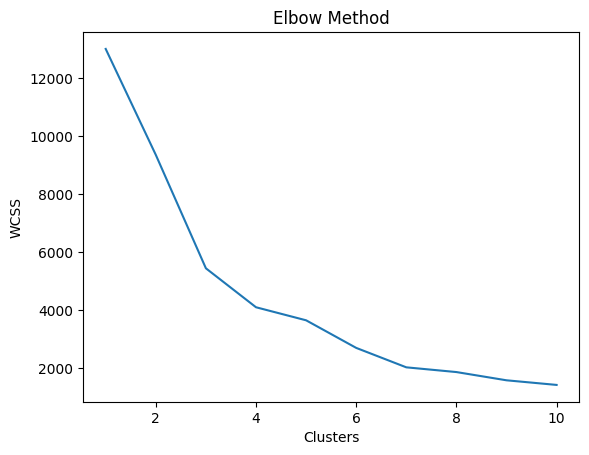

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [9]:
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         15.672986  22.047393   12435.086682
1        248.564030   1.551789     476.330547
2          7.384615  82.692308  127187.959231
3         43.910580   3.655748    1344.284013


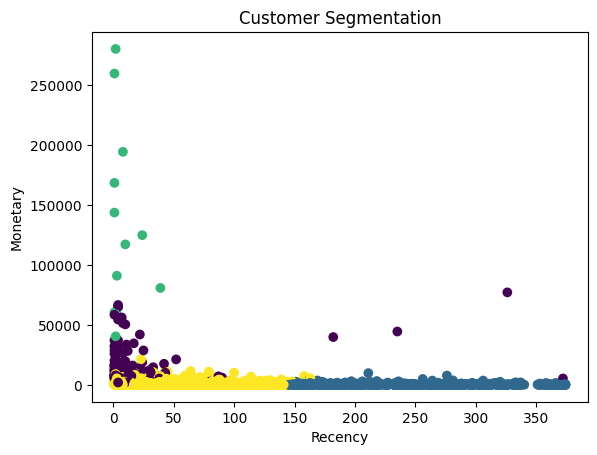

In [10]:
plt.figure()
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")
plt.show()

In [15]:
rfm.to_csv("../data/customer_segments.csv", index=True)

In [12]:
import pickle

# Save KMeans model
with open("../model/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)


In [13]:
import pickle

# Load model
loaded_kmeans = pickle.load(open("../model/kmeans_model.pkl", "rb"))

In [14]:
# Predict cluster for new data
new_clusters = loaded_kmeans.predict(rfm_scaled)

print(new_clusters[:5])

[0 3 3 3 1]
